1. Importar as bibliotecas

In [47]:
# Importação das bibliotecas que utilizaremos
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns

2. Definir a variável "file" pelo nome da planilha.

In [48]:
# Importação do arquivo de tabela a ser utilizado, através do path na seção "Files" do Colab, contendo as informações de resíduos sólidos
file='./Solid_waste_pt.xlsx'

3. Ler a planilha no Python.

In [49]:
# Visão geral da tabela
df=pd.read_excel(file)
df

,Regiao_Coleta,Tipo_Residuo,Origem_Residuo,Metodo_Destinacao,Massa_Coletada_kg,Densidade_Residuo_kgm3,Umidade_Residuo_pct,Distancia_Destinacao_km,Custo_Coleta_Transporte_RS_ton,Indice_Reciclabilidade_pct,Poder_Calorifico_MJkg
0,Zona Sul,Reciclável,Comercial,Aterro Sanitário,1057.3,80.8,2.0,14.7,138.7,79.7,15.1
1,Zona Oeste,Reciclável,Comercial,Reciclagem,533.3,82.4,2.0,9.1,119.1,85.4,17.9
2,Centro,Reciclável,Comercial,Reciclagem,529.7,72.7,2.0,24.0,223.2,81.6,13.9
3,Zona Oeste,Reciclável,Comercial,Reciclagem,486.3,67.4,2.0,3.6,117.9,82.0,18.8
4,Zona Leste,Reciclável,Comercial,Aterro Sanitário,527.1,40.0,2.0,16.7,164.2,88.0,14.7
...,...,...,...,...,...,...,...,...,...,...,...
285,Zona Leste,Orgânico,Residencial,Aterro Sanitário,275.9,371.8,77.0,17.2,178.8,5.2,6.5
286,Zona Norte,Orgânico,Comercial,Aterro Sanitário,471.8,338.4,77.2,52.9,262.3,5.0,8.1
287,Zona Leste,Orgânico,Residencial,Aterro Sanitário,356.3,341.2,77.6,18.0,184.2,10.1,3.6
288,Zona Oeste,Orgânico,Comercial,Reciclagem,674.9,316.9,78.5,5.1,94.1,8.1,8.8


In [50]:
#Organiza os dados dispostos na coluna Poder_Calorifico_MJkg em 3 grupos
classes = [0,10,20,30]
coluna='Poder_Calorifico_MJkg'
frequencia_Poder_Calorifico_MJkg = pd.value_counts(pd.cut(x=df[coluna],bins=classes,include_lowest=True,right=False))
frequencia_Poder_Calorifico_MJkg.sort_index(ascending=True)

/tmp/ipykernel_3833/813189447.py:4: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  frequencia_Poder_Calorifico_MJkg = pd.value_counts(pd.cut(x=df[coluna],bins=classes,include_lowest=True,right=False))


,count
Poder_Calorifico_MJkg,
"[0, 10)",124
"[10, 20)",132
"[20, 30)",34


In [51]:
#Calcula a frequência relativa para cada um desses grupos
frequencia_relativa_Poder_Calorifico_MJkg=round(pd.value_counts(pd.cut(x=df[coluna],bins=classes,include_lowest=True,right=False),normalize=True)*100,2)
frequencia_relativa_Poder_Calorifico_MJkg.sort_index(ascending=True)

/tmp/ipykernel_3833/527365694.py:2: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  frequencia_relativa_Poder_Calorifico_MJkg=round(pd.value_counts(pd.cut(x=df[coluna],bins=classes,include_lowest=True,right=False),normalize=True)*100,2)


,proportion
Poder_Calorifico_MJkg,
"[0, 10)",42.76
"[10, 20)",45.52
"[20, 30)",11.72


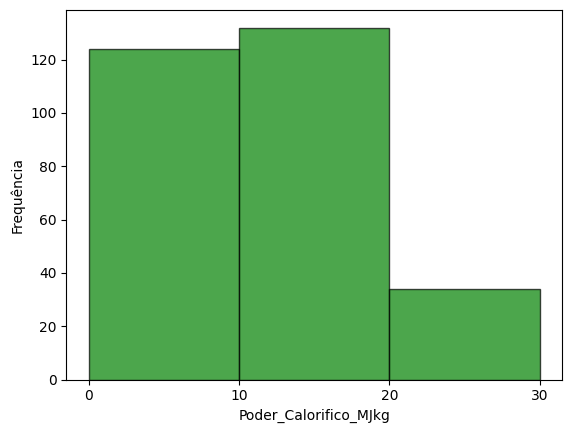

In [61]:
#Organiza em intervalos de mesmo tamanho e plota o histograma no final
classes=range(0,40,10)
plt.hist(df.Poder_Calorifico_MJkg,bins=classes,rwidth=1, color='green', alpha=0.7, edgecolor='black')
#Insere os marcadores no eixo x de acordo com o que foi definido
plt.xticks(ticks=[0, 10, 20, 30], labels=['0', '10', '20', '30'], rotation=0)
plt.xlabel("Poder_Calorifico_MJkg",size=10)
plt.ylabel("Frequência",size=10)
plt.show()

**Histograma**

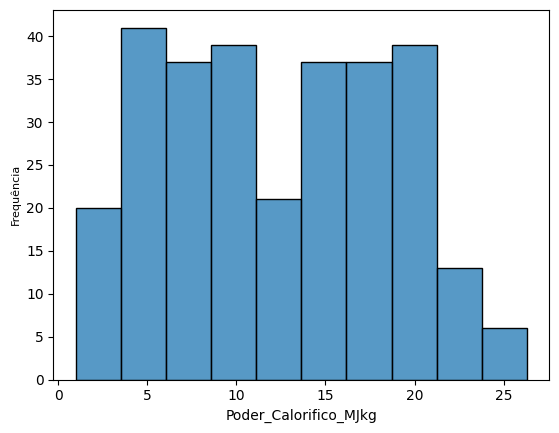

In [53]:
sns.histplot(data=df,x="Poder_Calorifico_MJkg",kde=False)
plt.ylabel("Frequência",size=8)
plt.show()

VALORES MÍNIMO E MÁXIMO DO CONJUNTO DE DADOS.

In [54]:
valormin=min(df.Poder_Calorifico_MJkg)
valormax=max(df.Poder_Calorifico_MJkg)
valormin,valormax

(1.0, 26.3)

**Medidas de Tendência Central**


*   Média, Moda e Mediana


In [55]:
#cálculo da Média, indicando Dataframe e a coluna em questão, no exemplo df.Poder_Calorifico_MJkg
df.Poder_Calorifico_MJkg.mean()

np.float64(12.241724137931033)

In [56]:
# com 2 casas decimais
df.Poder_Calorifico_MJkg.mean().round(2)

np.float64(12.24)

In [57]:
# cálculo da moda. Mesmas indicações
df.Poder_Calorifico_MJkg.mode()

,Poder_Calorifico_MJkg
0,8.8
1,19.2


In [58]:
#cálculo da mediana.
df.Poder_Calorifico_MJkg.median()

11.95

In [59]:
#comando describe mostra várias medidas das variáveis quantitativas, incluindo média e mediana.
df.Poder_Calorifico_MJkg.describe().round(2)

,Poder_Calorifico_MJkg
count,290.00
mean,12.24
std,6.21
min,1.00
25%,6.70
50%,11.95
75%,17.40
max,26.30
